Load the dataset

In [1]:
import pandas as pd
import numpy as np
import numpy.random as r
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score, confusion_matrix
)

np.random.seed(42)

Load the dataset

In [2]:
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Check missing values

In [3]:
df.isnull().sum().sort_values(ascending=False)

artists             1
album_name          1
track_name          1
Unnamed: 0          0
mode                0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
speechiness         0
key                 0
loudness            0
track_id            0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64

Check target distribution

In [4]:
df["track_genre"].value_counts().head(20)

track_genre
acoustic         1000
afrobeat         1000
alt-rock         1000
alternative      1000
ambient          1000
anime            1000
black-metal      1000
bluegrass        1000
blues            1000
brazil           1000
breakbeat        1000
british          1000
cantopop         1000
chicago-house    1000
children         1000
chill            1000
classical        1000
club             1000
comedy           1000
country          1000
Name: count, dtype: int64

Find the 10 most common genres, then make a new dataset that only includes songs from those genres.

In [5]:
top_10 = df["track_genre"].value_counts().head(10).index.tolist()

df_filtered = df[df["track_genre"].isin(top_10)].copy()

df_small = (
    df_filtered.groupby("track_genre", group_keys=False)
    .sample(n=200, random_state=42)
    .reset_index(drop=True)
)

print(df_small.shape)
print(df_small["track_genre"].value_counts())

(2000, 21)
track_genre
acoustic       200
afrobeat       200
alt-rock       200
alternative    200
ambient        200
anime          200
black-metal    200
bluegrass      200
blues          200
brazil         200
Name: count, dtype: int64


Select numeric audio features

In [6]:
features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

target = "track_genre"

X = df_small[features].copy()
y = df_small[target].copy()

print(X.shape)
print(y.shape)

(2000, 14)
(2000,)


Encode genre labels

In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Genres:", list(label_encoder.classes_))

Genres: ['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil']


Train/validation/test split. 700 training songs, 150 validation songs, 150 test songs.

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1400, 14)
Validation shape: (300, 14)
Test shape: (300, 14)


Scale the features

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# -------------- Neural Network

In [10]:
# One-hot encode targets
def to_onehot(y, n_classes=10):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

y_v_train = to_onehot(y_train)
y_v_val   = to_onehot(y_val)
y_v_test  = to_onehot(y_test)

print("y_v_train shape:", y_v_train.shape)
print("Example one-hot:", y_v_train[0])

y_v_train shape: (1400, 10)
Example one-hot: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


# Activation functions

In [11]:
def relu(z):
    """ReLU activation: max(0, z)"""
    return np.maximum(0, z)

def relu_deriv(z):
    """Derivative of ReLU"""
    return (z > 0).astype(float)

def softmax(z):
    """Numerically stable softmax"""
    e = np.exp(z - np.max(z))
    return e / e.sum()

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(z):
    return sigmoid(z) * (1 - sigmoid(z))

In [12]:
#Xavier weight initialization ----------

def init_weights(nn_structure, seed=42):
    """
    Xavier initialization: W ~ N(0, 1/fan_in)
    Much better than uniform [0,1) for sigmoid/ReLU networks.
    """
    np.random.seed(seed)
    W, b = {}, {}
    for l in range(1, len(nn_structure)):
        fan_in = nn_structure[l - 1]
        W[l] = np.random.randn(nn_structure[l], fan_in) * np.sqrt(1.0 / fan_in)
        b[l] = np.zeros(nn_structure[l])
    return W, b

def init_grads(nn_structure):
    tri_W, tri_b = {}, {}
    for l in range(1, len(nn_structure)):
        tri_W[l] = np.zeros((nn_structure[l], nn_structure[l-1]))
        tri_b[l] = np.zeros(nn_structure[l])
    return tri_W, tri_b

In [13]:
def feed_forward(x, W, b):
    """
    Hidden layers: ReLU
    Output layer:  Softmax
    Returns a (activations) and z (pre-activations) dicts.
    """
    n_layers = len(W)
    a = {1: x}
    z = {}
    for l in range(1, n_layers + 1):
        z[l+1] = W[l].dot(a[l]) + b[l]
        if l < n_layers:          # hidden layer → ReLU
            a[l+1] = relu(z[l+1])
        else:                     # output layer → Softmax
            a[l+1] = softmax(z[l+1])
    return a, z

In [14]:
#Loss: cross-entropy ----------
def cross_entropy(y_true, y_pred):
    """Cross-entropy for a single sample."""
    eps = 1e-12
    return -np.sum(y_true * np.log(y_pred + eps))

def compute_cost_batch(Y_true, X, W, b, lambda_reg):
    """
    Compute average cross-entropy loss + L2 regularization over a dataset.
    Y_true: (N, n_classes) one-hot matrix
    """
    N = X.shape[0]
    total = 0.0
    for i in range(N):
        a, _ = feed_forward(X[i], W, b)
        total += cross_entropy(Y_true[i], a[len(W)+1])
    total /= N
    # L2 penalty
    l2 = (lambda_reg / 2) * sum(np.sum(W[l]**2) for l in W)
    return total + l2

In [15]:
# Backpropagation & training ----------

def train_nn(nn_structure, X_train, y_v_train, X_val, y_v_val,
             n_iter=2000, alpha=0.05, lambda_reg=0.01, seed=42, verbose=True):
    """
    Train neural network with:
      - ReLU hidden activations
      - Softmax output
      - Cross-entropy loss
      - L2 regularization
      - Xavier weight init

    Returns: W, b, train_costs, val_costs
    """
    W, b = init_weights(nn_structure, seed=seed)
    n_layers = len(W)
    N = X_train.shape[0]
    train_costs, val_costs = [], []

    if verbose:
        print(f'  Training {nn_structure}, λ={lambda_reg}, α={alpha}')

    for cnt in range(n_iter):
        tri_W, tri_b = init_grads(nn_structure)

        for i in range(N):
            a, z = feed_forward(X_train[i], W, b)
            delta = {}

            # Output layer delta (softmax + cross-entropy simplifies to a - y)
            delta[n_layers + 1] = a[n_layers + 1] - y_v_train[i]

            # Hidden layer deltas (ReLU)
            for l in range(n_layers, 1, -1):
                delta[l] = W[l].T.dot(delta[l+1]) * relu_deriv(z[l])

            # Accumulate gradients
            for l in range(1, n_layers + 1):
                tri_W[l] += np.outer(delta[l+1], a[l])
                tri_b[l] += delta[l+1]

        #Gradient descent step with L2 regularization
        for l in range(1, n_layers + 1):
            W[l] -= alpha * (tri_W[l] / N + lambda_reg * W[l])
            b[l] -= alpha * (tri_b[l] / N)

        #Record costs every 100 iterations (saves time)
        if cnt % 100 == 0:
            tc = compute_cost_batch(y_v_train, X_train, W, b, lambda_reg)
            vc = compute_cost_batch(y_v_val,   X_val,   W, b, lambda_reg)
            train_costs.append(tc)
            val_costs.append(vc)

    return W, b, train_costs, val_costs


def predict(W, b, X):
    """Predict class labels for dataset X."""
    n_layers = len(W) + 1
    preds = []
    for i in range(X.shape[0]):
        a, _ = feed_forward(X[i], W, b)
        preds.append(np.argmax(a[n_layers]))
    return np.array(preds)

In [16]:
ARCHITECTURES = {
    "T0_Linear":      [14, 10],
    "T1_Shallow":     [14, 30, 10],
    "T2_DeeperNarrow":[14, 20, 20, 10],
    "T3_Wider":       [14, 64, 10],
    "T4_DeepWide":    [14, 64, 32, 10],
}

LAMBDA_VALUES = [0, 0.0001, 0.001, 0.01, 0.1, 1.0]

# Training hyperparameters (same for all to ensure fair comparison)
N_ITER  = 2000
ALPHA   = 0.05

#Total experiments: 5 architectures × 6 λ values = 30 models

In [17]:
#ALL EXPERIMENTS: Train each architecture with each λ, record results and curves

results = []      # list of result dicts → becomes the results table
curves  = {}      # {(arch_name, lambda): (train_costs, val_costs)}
models  = {}      # {(arch_name, lambda): (W, b)} — keep best for final eval

for arch_name, nn_structure in ARCHITECTURES.items():
    print(f"\n{'='*55}")
    print(f"Architecture: {arch_name}  {nn_structure}")
    print(f"{'='*55}")

    for lam in LAMBDA_VALUES:
        W, b, train_costs, val_costs = train_nn(
            nn_structure,
            X_train_scaled, y_v_train,
            X_val_scaled,   y_v_val,
            n_iter=N_ITER, alpha=ALPHA, lambda_reg=lam,
            verbose=True
        )

        # Evaluate on train and validation
        y_pred_train = predict(W, b, X_train_scaled)
        y_pred_val   = predict(W, b, X_val_scaled)

        train_acc = accuracy_score(y_train, y_pred_train)
        val_acc   = accuracy_score(y_val,   y_pred_val)
        val_prec  = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
        val_rec   = recall_score(y_val, y_pred_val, average='macro', zero_division=0)
        val_f1    = f1_score(y_val, y_pred_val, average='macro', zero_division=0)

        results.append({
            'Architecture':  arch_name,
            'Structure':     str(nn_structure),
            'Lambda':        lam,
            'Train Acc':     round(train_acc, 4),
            'Val Acc':       round(val_acc,   4),
            'Val Precision': round(val_prec,  4),
            'Val Recall':    round(val_rec,   4),
            'Val F1':        round(val_f1,    4),
            'Final Train Loss': round(train_costs[-1], 4),
            'Final Val Loss':   round(val_costs[-1],   4),
        })

        curves[(arch_name, lam)]  = (train_costs, val_costs)
        models[(arch_name, lam)]  = (W, b)

        print(f"    λ={lam:<8} | Train: {train_acc:.3f} | Val: {val_acc:.3f} | F1: {val_f1:.3f}")

print("\nAll experiments complete.")


Architecture: T0_Linear  [14, 10]
  Training [14, 10], λ=0, α=0.05
    λ=0        | Train: 0.480 | Val: 0.457 | F1: 0.448
  Training [14, 10], λ=0.0001, α=0.05
    λ=0.0001   | Train: 0.479 | Val: 0.457 | F1: 0.448
  Training [14, 10], λ=0.001, α=0.05


KeyboardInterrupt: 

# Results

In [ ]:
results_df = pd.DataFrame(results)

# Highlight the row with best validation accuracy per architecture
best_per_arch = results_df.loc[results_df.groupby('Architecture')['Val Acc'].idxmax()]

print("\nBest model per architecture (by Val Acc):")
print(best_per_arch[['Architecture','Lambda','Train Acc','Val Acc','Val F1']].to_string(index=False))

# Overall best
best_row = results_df.loc[results_df['Val Acc'].idxmax()]
print(f"\nOverall best: {best_row['Architecture']}  λ={best_row['Lambda']}  Val Acc={best_row['Val Acc']:.4f}")

In [ ]:
# --- Plot 1: Validation Accuracy vs Lambda, per architecture ---

fig, ax = plt.subplots(figsize=(10, 6))
lambda_labels = [str(l) for l in LAMBDA_VALUES]
x = np.arange(len(LAMBDA_VALUES))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, arch_name in enumerate(ARCHITECTURES):
    arch_results = results_df[results_df['Architecture'] == arch_name].sort_values('Lambda')
    ax.plot(x, arch_results['Val Acc'].values, marker='o', linewidth=2,
            color=colors[i], label=arch_name)

ax.set_xticks(x)
ax.set_xticklabels(lambda_labels)
ax.set_xlabel('Regularization (λ)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Validation Accuracy vs. Regularization Strength\nby Architecture', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 2: Learning curves for each architecture at λ=0.001 ---

PLOT_LAMBDA = 0.001  # change this to inspect other lambda values
iters = np.arange(0, N_ITER, 100)

fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(18, 4), sharey=False)

for i, arch_name in enumerate(ARCHITECTURES):
    tc, vc = curves[(arch_name, PLOT_LAMBDA)]
    axes[i].plot(iters, tc, label='Train', color='steelblue')
    axes[i].plot(iters, vc, label='Val',   color='tomato')
    axes[i].set_title(arch_name.replace('_', '\n'), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Iteration', fontsize=9)
    if i == 0:
        axes[i].set_ylabel('Cross-Entropy Loss', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f'Learning Curves (λ = {PLOT_LAMBDA})', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 3: Train vs Val accuracy (bias-variance view) ---

fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(18, 5), sharey=True)

for i, arch_name in enumerate(ARCHITECTURES):
    arch_results = results_df[results_df['Architecture'] == arch_name].sort_values('Lambda')
    x = np.arange(len(LAMBDA_VALUES))
    axes[i].plot(x, arch_results['Train Acc'].values, 'o--', color='steelblue', label='Train')
    axes[i].plot(x, arch_results['Val Acc'].values,   's-',  color='tomato',    label='Val')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([str(l) for l in LAMBDA_VALUES], rotation=45, ha='right', fontsize=8)
    axes[i].set_title(arch_name.replace('_', '\n'), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('λ', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_ylabel('Accuracy', fontsize=11)
    axes[i].legend(fontsize=8)

fig.suptitle('Train vs. Validation Accuracy by Architecture (Bias-Variance Tradeoff)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 4: Precision, Recall, F1 for best model per architecture ---

metrics = ['Val Precision', 'Val Recall', 'Val F1']
x = np.arange(len(ARCHITECTURES))
width = 0.25
arch_names = list(ARCHITECTURES.keys())

fig, ax = plt.subplots(figsize=(12, 6))
for j, metric in enumerate(metrics):
    vals = [best_per_arch[best_per_arch['Architecture'] == a][metric].values[0]
            for a in arch_names]
    ax.bar(x + j*width, vals, width, label=metric)

ax.set_xticks(x + width)
ax.set_xticklabels([a.replace('_', '\n') for a in arch_names], fontsize=9)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision / Recall / F1 — Best Model per Architecture', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 5: Learning curves for best architecture across all lambda values ---

BEST_ARCH = best_row['Architecture']
iters = np.arange(0, N_ITER, 100)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, lam in enumerate(LAMBDA_VALUES):
    tc, vc = curves[(BEST_ARCH, lam)]
    axes[i].plot(iters, tc, label='Train', color='steelblue')
    axes[i].plot(iters, vc, label='Val',   color='tomato')
    axes[i].set_title(f'λ = {lam}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Loss')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f'Learning Curves — {BEST_ARCH} — All λ values',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Final Eval on test

In [ ]:
# Identify best model from validation results
best_arch = best_row['Architecture']
best_lam  = best_row['Lambda']

print(f"Best model selected: {best_arch}  λ={best_lam}")
print(f"Validation accuracy: {best_row['Val Acc']:.4f}")
print("-" * 50)

W_best, b_best = models[(best_arch, best_lam)]

# Evaluate on test set
y_pred_test = predict(W_best, b_best, X_test)

test_acc  = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
test_rec  = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
test_f1   = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

print(f"TEST Accuracy:  {test_acc:.4f}")
print(f"TEST Precision: {test_prec:.4f}")
print(f"TEST Recall:    {test_rec:.4f}")
print(f"TEST F1:        {test_f1:.4f}")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_test,
                             target_names=label_encoder.classes_))

# Logistic Regression

We will be using softmax for multi class logistic regression.

In [18]:
import matplotlib.pyplot as plt
import numpy as numpy
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [19]:
def logistic_model(C, solver_, multiclass_):
    logistic_regression_model = LogisticRegression(random_state=42, solver=solver_, multi_class=multiclass_, n_jobs=1, C=C)
    return logistic_regression_model


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

multiclass = ['ovr', 'multinomial']
solver_list = ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']
c_values = [0.01, 0.1, 1, 10, 50, 100]
lr_results = []

for c in c_values:
    for i in multiclass:
        for j in solver_list:
            try:
                model = logistic_model(c, j, i)
                model.fit(X_train_scaled, y_train)

                y_train_pred = model.predict(X_train_scaled)
                y_val_pred = model.predict(X_val_scaled)

                lr_results.append({
                    "model": "Logistic Regression",
                    "multiclass": i,
                    "solver": j,
                    "C": c,
                    "train_accuracy": accuracy_score(y_train, y_train_pred),
                    "val_accuracy": accuracy_score(y_val, y_val_pred),
                    "val_precision": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
                    "val_recall": recall_score(y_val, y_val_pred, average="macro", zero_division=0),
                    "val_f1": f1_score(y_val, y_val_pred, average="macro", zero_division=0)
                })

            except ValueError as e:
                print(f"Skipping C={c} | {i} + {j}: {e}")


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

The results table

In [ ]:
# Convert to DataFrame for a clean results table
lr_results_df = pd.DataFrame(lr_results)
lr_results_df.sort_values("val_f1", ascending=False)

,model,multiclass,solver,C,train_accuracy,val_accuracy,val_precision,val_recall,val_f1
23,Logistic Regression,multinomial,newton-cg,1.00,0.595714,0.626667,0.618742,0.626667,0.615066
26,Logistic Regression,multinomial,saga,1.00,0.595000,0.626667,0.618742,0.626667,0.615066
25,Logistic Regression,multinomial,sag,1.00,0.595000,0.626667,0.618742,0.626667,0.615066
24,Logistic Regression,multinomial,lbfgs,1.00,0.595000,0.626667,0.618742,0.626667,0.615066
53,Logistic Regression,multinomial,saga,100.00,0.595714,0.623333,0.615377,0.623333,0.611544
35,Logistic Regression,multinomial,saga,10.00,0.595714,0.623333,0.615377,0.623333,0.611544
34,Logistic Regression,multinomial,sag,10.00,0.595714,0.623333,0.615377,0.623333,0.611544
32,Logistic Regression,multinomial,newton-cg,10.00,0.595714,0.623333,0.615377,0.623333,0.611544
44,Logistic Regression,multinomial,saga,50.00,0.595714,0.623333,0.615377,0.623333,0.611544
51,Logistic Regression,multinomial,lbfgs,100.00,0.597143,0.623333,0.614956,0.623333,0.611303


Line plot of Val Accuracy vs C value

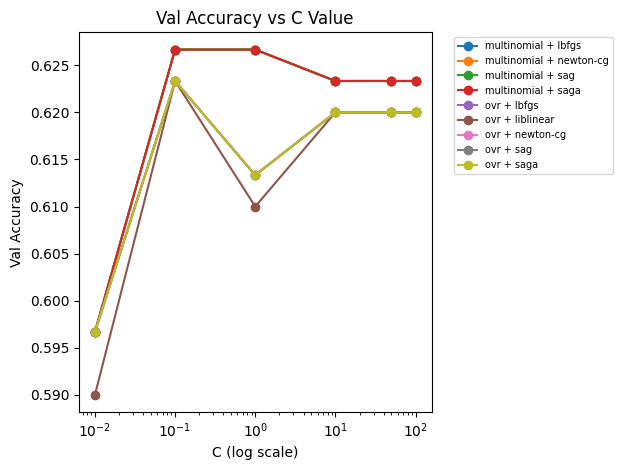

In [ ]:
for combo, group in lr_results_df.groupby(['multiclass', 'solver']):
    plt.plot(group['C'], group['val_accuracy'], marker='o', label=f"{combo[0]} + {combo[1]}")

plt.xscale('log')  # C values span orders of magnitude
plt.xlabel('C (log scale)')
plt.ylabel('Val Accuracy')
plt.title('Val Accuracy vs C Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

Bar charts of val F1

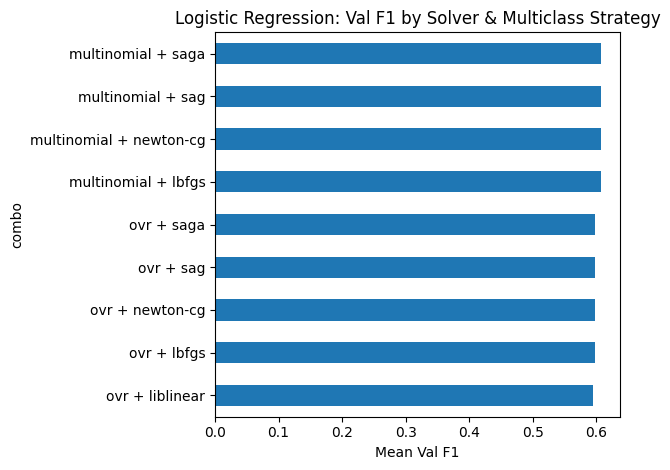

In [ ]:
lr_results_df['combo'] = lr_results_df['multiclass'] + ' + ' + lr_results_df['solver']
lr_results_df.groupby('combo')['val_f1'].mean().sort_values().plot(kind='barh')
plt.xlabel('Mean Val F1')
plt.title('Logistic Regression: Val F1 by Solver & Multiclass Strategy')
plt.tight_layout()
plt.show()

SVM

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Log-tranformed features

In [11]:
X_train_log = X_train.copy()
X_val_log = X_val.copy()
X_test_log = X_test.copy()

for col in ["duration_ms", "tempo", "popularity"]:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_val_log[col] = np.log1p(X_val_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])

scaler_log = StandardScaler()

X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_val_log_scaled = scaler_log.transform(X_val_log)
X_test_log_scaled = scaler_log.transform(X_test_log)

PCA features

In [12]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train_scaled.shape)
print("PCA shape:", X_train_pca.shape)

Original shape: (1400, 14)
PCA shape: (1400, 12)


Polynomial features

In [13]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Polynomial shape:", X_train_poly.shape)

Polynomial shape: (1400, 119)


Store the 4 feature sets

In [14]:
svm_feature_sets = {
    "original": (X_train_scaled, X_val_scaled, X_test_scaled),
    "pca": (X_train_pca, X_val_pca, X_test_pca),
    "polynomial": (X_train_poly, X_val_poly, X_test_poly),
    "log": (X_train_log_scaled, X_val_log_scaled, X_test_log_scaled)
}

In [15]:
svm_results = []
C_values = [0.01, 0.1, 1, 10, 50, 100]

for feature_name, (Xtr, Xv, Xt) in svm_feature_sets.items():
    for c in C_values:
        model = SVC(kernel="rbf", C=c, gamma="scale")
        model.fit(Xtr, y_train)

        y_train_pred = model.predict(Xtr)
        y_val_pred = model.predict(Xv)

        svm_results.append({
            "model": "SVM",
            "feature_set": feature_name,
            "C": c,
            "train_accuracy": accuracy_score(y_train, y_train_pred),
            "val_accuracy": accuracy_score(y_val, y_val_pred),
            "val_precision": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_recall": recall_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_f1": f1_score(y_val, y_val_pred, average="macro", zero_division=0)
        })

The results table

In [17]:
svm_results_df = pd.DataFrame(svm_results)
print("Number of SVM models trained:", len(svm_results_df))
svm_results_df.sort_values(by="val_accuracy", ascending=False).head(24)

Number of SVM models trained: 24


,model,feature_set,C,train_accuracy,val_accuracy,val_precision,val_recall,val_f1
15,SVM,polynomial,10.00,0.875000,0.550000,0.557025,0.550000,0.548326
3,SVM,original,10.00,0.882143,0.546667,0.548995,0.546667,0.541749
20,SVM,log,1.00,0.660000,0.540000,0.542081,0.540000,0.533709
2,SVM,original,1.00,0.684286,0.540000,0.540056,0.540000,0.531712
8,SVM,pca,1.00,0.664286,0.536667,0.536175,0.536667,0.528906
9,SVM,pca,10.00,0.856429,0.536667,0.549774,0.536667,0.538744
21,SVM,log,10.00,0.874286,0.536667,0.553621,0.536667,0.537703
17,SVM,polynomial,100.00,0.972857,0.520000,0.533748,0.520000,0.520509
16,SVM,polynomial,50.00,0.957143,0.520000,0.539251,0.520000,0.521391
14,SVM,polynomial,1.00,0.695714,0.516667,0.530372,0.516667,0.515627


Validation accuracy vs C for each feature set

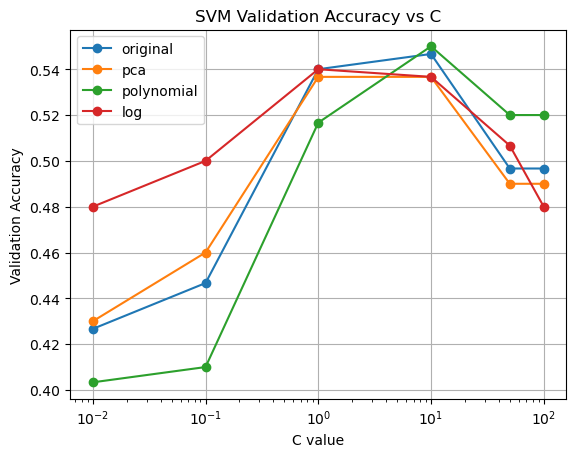

In [18]:
for feature_name in svm_results_df["feature_set"].unique():
    subset = svm_results_df[svm_results_df["feature_set"] == feature_name]
    plt.plot(subset["C"], subset["val_accuracy"], marker="o", label=feature_name)

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Validation Accuracy")
plt.title("SVM Validation Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()

Bar chart of best validation accuracy by feature set